In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Ellipse
from matplotlib import colormaps
from IPython.display import HTML

from torch.nn.functional import conv2d, avg_pool2d
import torch
from torch import pi
from torch import where
from torch import Tensor

import caskade as ck
import caustics
from caustics import Module, forward, Param
from caustics import utils


from typing import Optional, Union, Annotated
from caskade import forward, Param
# from .base import Source, NameType
# from . import func

import copy
import h5py
import os
import scipy
import sncosmo
from PIL import Image
import galsim

from astropy.cosmology import WMAP9 as cosmo
from astropy.table import Table
from astropy.io import fits
from astropy import wcs

import matplotlib as mpl
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'serif'

In [9]:
# LSST g, r, i
# lsst_read_noise_g, lsst_read_noise_r, lsst_read_noise_i             = 10, 10, 10
# lsst_pixel_scale_g, lsst_pixel_scale_r, lsst_pixel_scale_i          = 0.2, 0.2, 0.2
# lsst_ccd_gain_g, lsst_ccd_gain_r, lsst_ccd_gain_i                   = 2.3, 2.3, 2.3
# lsst_exposure_time_g, lsst_exposure_time_r, lsst_exposure_time_i    = 15.0, 15.0, 15.0
lsst_read_noise = 10
lsst_pixel_scale = 0.2
lsst_ccd_gain = 2.3
lsst_exposure_time = 15.0
lsst_sky_brightness_g, lsst_sky_brightness_r, lsst_sky_brightness_i = 22.26, 21.2, 20.48     #AB mag arcsec-2
lsst_mag_zero_point_g, lsst_mag_zero_point_r, lsst_mag_zero_point_i = 28.3, 28.13, 27.79
lsst_num_exposures_g, lsst_num_exposures_r, lsst_num_exposures_i    = 200, 460, 460
lsst_seeing_g, lsst_seeing_r, lsst_seeing_i                         = 0.77, 0.73,  0.71      # FWHM arcsec

# Roman  F062, F106, F184
# roman_read_noise_g, roman_read_noise_r, roman_read_noise_i          = 15.5, 15.5, 15.5
# roman_pixel_scale_g, roman_pixel_scale_r, roman_pixel_scale_i       = 0.11, 0.11, 0.11
# roman_ccd_gain_g, roman_ccd_gain_r, roman_ccd_gain_i                =  1, 1, 1
roman_read_noise = 15.5
roman_pixel_scale = 0.11
roman_ccd_gain = 1
roman_sky_brightness_g, roman_sky_brightness_r, roman_sky_brightness_i = 23.19, 22.99, 23.22
roman_magnitude_zero_point_g, roman_magnitude_zero_point_r, roman_magnitude_zero_point_i = 26.56, 26.44, 25.95
roman_seeing_g, roman_seeing_r, roman_seeing_i                      =  0.058, 0.087, 0.151
roman_exposure_time_g, roman_exposure_time_r, roman_exposure_time_i = 146, 146, 146
roman_num_exposures_g, roman_num_exposures_r, roman_num_exposures_i = 96, 96, 96

# Dictionary 
telescope_params = {
    'LSST': {
        'read_noise': 10.0,
        'exposure_time': 15.0,
        'pixel_scale': 0.2, 
        'ccd_gain': 2.3,
        'sky_brightness_mags': {'g': 22.26, 'r': 21.2, 'i': 20.48},
        'zero_points_mags': {'g': 28.3, 'r': 28.13, 'i': 27.79},
        'num_exposures': {'g': 200, 'r': 460, 'i': 460}
    },
    'Roman': {
        'read_noise': 15.5,
        'exposure_time': 146.0,
        'pixel_scale': 0.11, 
        'ccd_gain': 1,
        'sky_brightness_mags': {'g': 23.19, 'r': 22.99, 'i': 23.22}, # mapped to F062, F106, F184
        'zero_points_mags': {'g': 26.56, 'r': 26.44, 'i': 25.95},
        'num_exposures': {'g': 96, 'r': 96, 'i': 96}
    }
}

In [10]:
## Get size of PSF
## code from: https://github.com/lenstronomy/lenstronomy/blob/main/lenstronomy/Data/psf.py
import lenstronomy
from lenstronomy.Util import util, kernel_util

def kernel_point_source(fwhm, pixel_size, truncation=5):
    sigma = util.fwhm2sigma(fwhm)
    # This num_pix definition is equivalent to that of the scipy ndimage.gaussian_filter
    # num_pix = 2r + 1 where r = round(truncation * sigma) is the radius of the gaussian kernel
    # kernel_num_pix is always an odd integer between 3 and 221
    kernel_radius = max(
        round(truncation * sigma / pixel_size), 1
    )
    kernel_num_pix = min(2 * kernel_radius + 1, 221)
    
    kernel_point_source = kernel_util.kernel_gaussian(
        kernel_num_pix, pixel_size, fwhm
    )
    return kernel_num_pix

lsst_n_psf_g = kernel_point_source(lsst_seeing_g, lsst_pixel_scale)
print(f"Rubin g-band n_psf: {lsst_n_psf_g}")
lsst_n_psf_r = kernel_point_source(lsst_seeing_r, lsst_pixel_scale)
print(f"Rubin r-band n_psf: {lsst_n_psf_r}")
lsst_n_psf_i = kernel_point_source(lsst_seeing_i, lsst_pixel_scale)
print(f"Rubin i-band n_psf: {lsst_n_psf_i}")

print('\n')
roman_n_psf_g = kernel_point_source(roman_seeing_g, roman_pixel_scale)
print(f"Roman g-band n_psf: {roman_n_psf_g}")
roman_n_psf_r = kernel_point_source(roman_seeing_r, roman_pixel_scale)
print(f"Roman r-band n_psf: {roman_n_psf_r}")
roman_n_psf_i = kernel_point_source(roman_seeing_i, roman_pixel_scale)
print(f"Roman i-band n_psf: {roman_n_psf_i}")

Rubin g-band n_psf: 17
Rubin r-band n_psf: 17
Rubin i-band n_psf: 17


Roman g-band n_psf: 3
Roman r-band n_psf: 5
Roman i-band n_psf: 7


# Change size manually

In [11]:
def gaussian(pixelscale, nx, ny, sigma, upsample=1, dtype=torch.float32, device=None):
    X, Y = torch.meshgrid(
        torch.linspace(
            -(nx * upsample - 1) * pixelscale / 2,
            (nx * upsample - 1) * pixelscale / 2,
            nx * upsample,
            dtype=dtype,
            device=device,
        ),
        torch.linspace(
            -(ny * upsample - 1) * pixelscale / 2,
            (ny * upsample - 1) * pixelscale / 2,
            ny * upsample,
            dtype=dtype,
            device=device,
        ),
        indexing="xy",
    )

    Z = torch.exp(-0.5 * (X**2 + Y**2) / sigma**2)

    # Z = backend.sum(Z.reshape(ny, upsample, nx, upsample), dim=(1, 3))

    return Z / torch.sum(Z)

In [12]:
# Rubin/LSST PSF and image resolution
oversamplefactor = 4

lsst_psf_dict = {}
bands = ["g","r","i"]
lsst_seeings = [lsst_seeing_g, lsst_seeing_r, lsst_seeing_i]
lsst_n_psfs = [lsst_n_psf_g, lsst_n_psf_r, lsst_n_psf_i]

for band, fwhm, lsst_n_psf in zip(bands, lsst_seeings, lsst_n_psfs):
    lsst_psf_sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    
    lsst_psf_dict[band] = gaussian(
        nx=lsst_n_psf, 
        ny=lsst_n_psf, 
        pixelscale = lsst_pixel_scale, 
        sigma=lsst_psf_sigma, 
        upsample=1
    )


# Roman PSF and image resolution
roman_psf_dict = {}
bands = ["g","r","i"]
roman_seeings = [roman_seeing_g, roman_seeing_r, roman_seeing_i]
roman_n_psfs = [roman_n_psf_g, roman_n_psf_r, roman_n_psf_i]

for band, fwhm, roman_n_psf in zip(bands, roman_seeings, roman_n_psfs):
    roman_psf_sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    
    roman_psf_dict[band] = gaussian(
        nx=lsst_n_psf, 
        ny=lsst_n_psf,   # Set them all (both Rubin and Roman) to 17 (i.e. actual Rubin value) for now
        pixelscale = roman_pixel_scale, 
        sigma=roman_psf_sigma, 
        upsample=oversamplefactor
    )


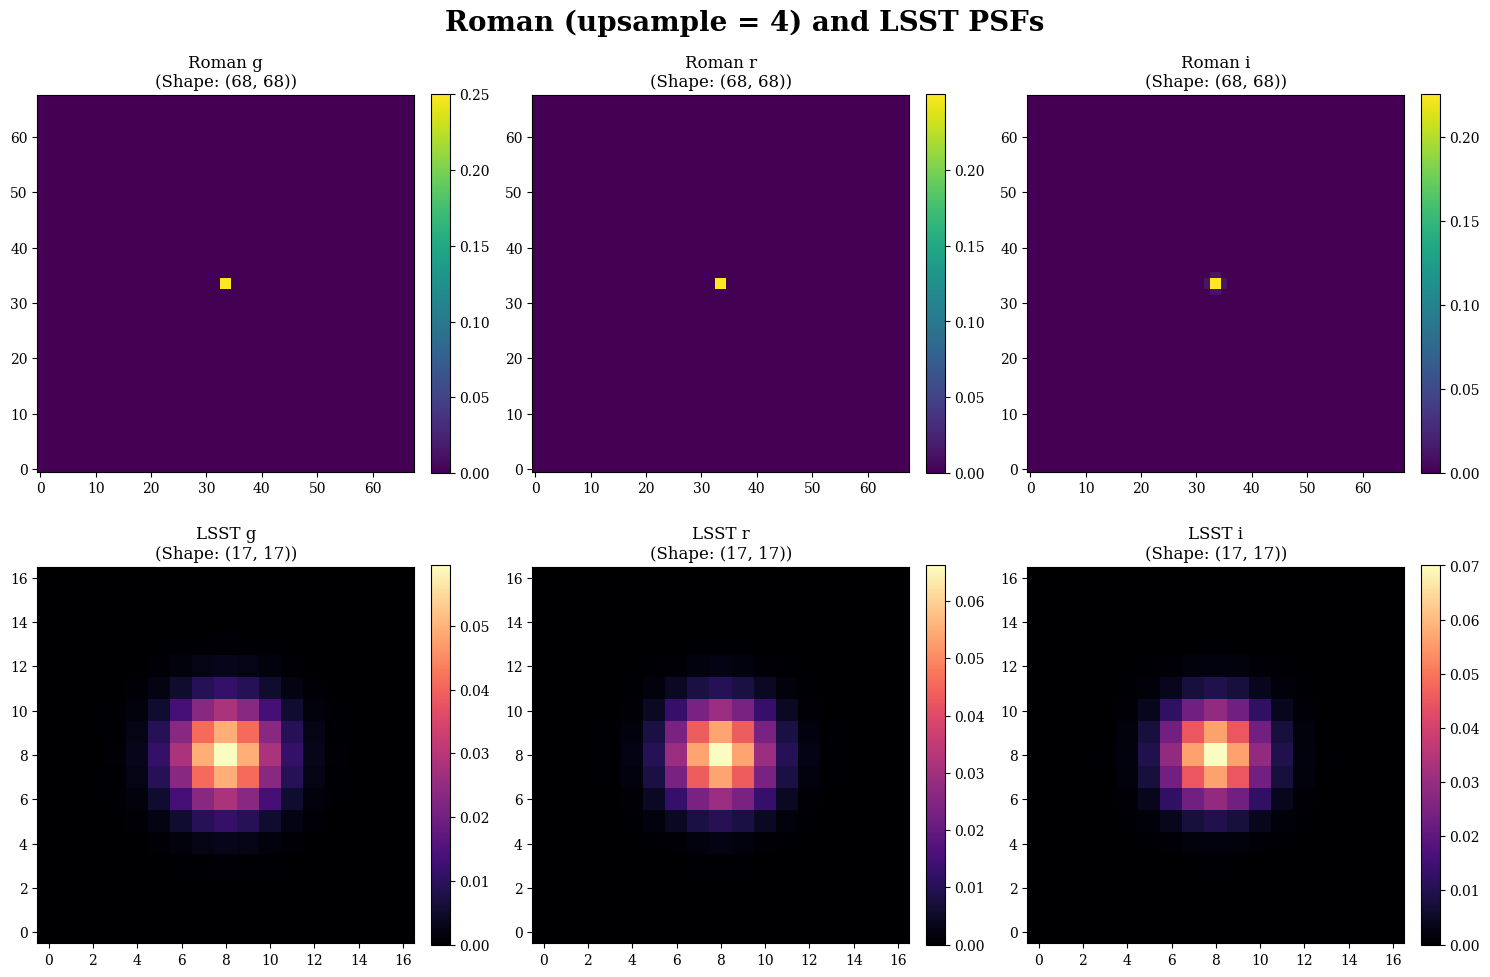

Sum of PSF pixels (should be 1.0):
Roman g: 1.0000
LSST g:  1.0000
Roman r: 1.0000
LSST r:  1.0000
Roman i: 1.0000
LSST i:  1.0000


In [14]:
# Sanity check
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=False, sharey=False)
# Plot Roman PSFs 
for i, band in enumerate(["g", "r", "i"]):
    data = roman_psf_dict[band].detach().cpu().numpy()
    im = axes[0, i].imshow(data, origin='lower', cmap='viridis')
    axes[0, i].set_title(f"Roman {band}\n(Shape: {data.shape})")
    fig.colorbar(im, ax=axes[0, i], fraction=0.046, pad=0.04)
    # axes[0, i].set_ylim(30, 38)
    # axes[0, i].set_xlim(30, 38)

# Plot LSST PSFs
for i, band in enumerate(["g", "r", "i"]):
    data = lsst_psf_dict[band].detach().cpu().numpy()
    im = axes[1, i].imshow(data, origin='lower', cmap='magma')
    axes[1, i].set_title(f"LSST {band}\n(Shape: {data.shape})")
    fig.colorbar(im, ax=axes[1, i], fraction=0.046, pad=0.04)



plt.suptitle("Roman (upsample = "+str(oversamplefactor)+") and LSST PSFs", fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# Check for normalization (should all be 1.0)
print("Sum of PSF pixels (should be 1.0):")
for band in ["g", "r", "i"]:
    print(f"Roman {band}: {roman_psf_dict[band].sum().item():.4f}")
    print(f"LSST {band}:  {lsst_psf_dict[band].sum().item():.4f}")

In [15]:
##Save Roman PSFs
np.save("PSFs/caustics_gaussian_psf_Roman_g_size_17_oversample"+str(oversamplefactor)+".npy", roman_psf_dict["g"].detach().cpu().numpy())
np.save("PSFs/caustics_gaussian_psf_Roman_r_size_17_oversample"+str(oversamplefactor)+".npy", roman_psf_dict["r"].detach().cpu().numpy())
np.save("PSFs/caustics_gaussian_psf_Roman_i_size_17_oversample"+str(oversamplefactor)+".npy", roman_psf_dict["i"].detach().cpu().numpy())

# # Save Rubin PSFs
# np.save("caustics_gaussian_psf_LSST_g_size_17.npy", lsst_psf_dict["g"].detach().cpu().numpy())
# np.save("caustics_gaussian_psf_LSST_r_size_17.npy", lsst_psf_dict["r"].detach().cpu().numpy())
# np.save("caustics_gaussian_psf_LSST_i_size_17.npy", lsst_psf_dict["i"].detach().cpu().numpy())

print("All 6 PSF files have been saved as .npy files.")

All 6 PSF files have been saved as .npy files.


# Original caustics oversample

In [4]:
# Rubin/LSST PSF and image resolution
lsst_psf_dict = {}
bands = ["g","r","i"]
lsst_seeings = [lsst_seeing_g, lsst_seeing_r, lsst_seeing_i]
lsst_n_psfs = [lsst_n_psf_g, lsst_n_psf_r, lsst_n_psf_i]

oversample_factor = 4

for band, fwhm, lsst_n_psf in zip(bands, lsst_seeings, lsst_n_psfs):
    lsst_psf_sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    
    lsst_psf_dict[band] = caustics.utils.gaussian(
        nx=lsst_n_psf, 
        ny=lsst_n_psf, 
        pixelscale = lsst_pixel_scale, 
        sigma=lsst_psf_sigma, 
        upsample=1
    )


# Roman PSF and image resolution
roman_psf_dict = {}
bands = ["g","r","i"]
roman_seeings = [roman_seeing_g, roman_seeing_r, roman_seeing_i]
roman_n_psfs = [roman_n_psf_g, roman_n_psf_r, roman_n_psf_i]

for band, fwhm, roman_n_psf in zip(bands, roman_seeings, roman_n_psfs):
    roman_psf_sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    
    roman_psf_dict[band] = caustics.utils.gaussian(
        nx=lsst_n_psf, 
        ny=lsst_n_psf,   # Set them all (both Rubin and Roman) to 17 (i.e. actual Rubin value) for now
        pixelscale = roman_pixel_scale, 
        sigma=roman_psf_sigma, 
        upsample=oversample_factor
    )

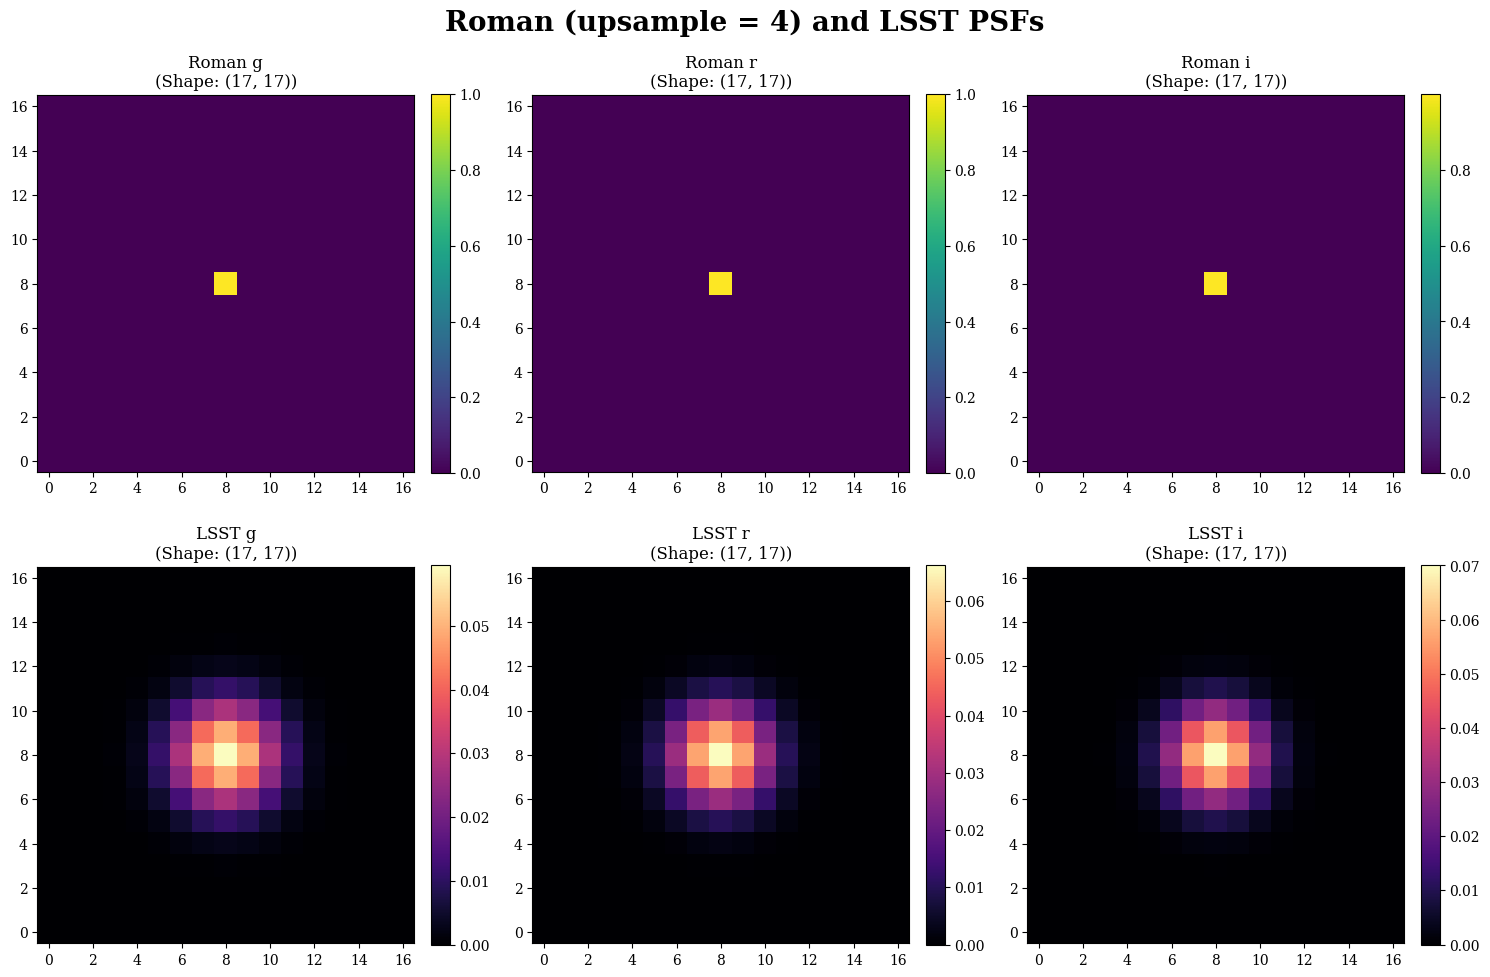

Sum of PSF pixels (should be 1.0):
Roman g: 1.0000
LSST g:  1.0000
Roman r: 1.0000
LSST r:  1.0000
Roman i: 1.0000
LSST i:  1.0000


In [5]:
# Sanity check
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=False, sharey=False)
# Plot Roman PSFs 
for i, band in enumerate(["g", "r", "i"]):
    data = roman_psf_dict[band].detach().cpu().numpy()
    im = axes[0, i].imshow(data, origin='lower', cmap='viridis')
    axes[0, i].set_title(f"Roman {band}\n(Shape: {data.shape})")
    fig.colorbar(im, ax=axes[0, i], fraction=0.046, pad=0.04)
# Plot LSST PSFs
for i, band in enumerate(["g", "r", "i"]):
    data = lsst_psf_dict[band].detach().cpu().numpy()
    im = axes[1, i].imshow(data, origin='lower', cmap='magma')
    axes[1, i].set_title(f"LSST {band}\n(Shape: {data.shape})")
    fig.colorbar(im, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.suptitle("Roman (upsample = 4) and LSST PSFs", fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# Check for normalization (should all be 1.0)
print("Sum of PSF pixels (should be 1.0):")
for band in ["g", "r", "i"]:
    print(f"Roman {band}: {roman_psf_dict[band].sum().item():.4f}")
    print(f"LSST {band}:  {lsst_psf_dict[band].sum().item():.4f}")

In [6]:
# #Save Roman PSFs
# np.save("PSFs/caustics_gaussian_psf_Roman_g_size_17.npy", roman_psf_dict["g"].detach().cpu().numpy())
# np.save("PSFs/caustics_gaussian_psf_Roman_r_size_17.npy", roman_psf_dict["r"].detach().cpu().numpy())
# np.save("PSFs/caustics_gaussian_psf_Roman_i_size_17.npy", roman_psf_dict["i"].detach().cpu().numpy())

# # Save Rubin PSFs
# np.save("PSFs/caustics_gaussian_psf_LSST_g_size_17.npy", lsst_psf_dict["g"].detach().cpu().numpy())
# np.save("PSFs/caustics_gaussian_psf_LSST_r_size_17.npy", lsst_psf_dict["r"].detach().cpu().numpy())
# np.save("PSFs/caustics_gaussian_psf_LSST_i_size_17.npy", lsst_psf_dict["i"].detach().cpu().numpy())

# print("All 6 PSF files have been saved as .npy files.")

In [7]:
# ##Save Roman upsampled PSFs
# np.save("PSFs/caustics_gaussian_psf_Roman_g_size_17_oversample"+str(oversample_factor)+".npy", roman_psf_dict["g"].detach().cpu().numpy())
# np.save("PSFs/caustics_gaussian_psf_Roman_r_size_17_oversample"+str(oversample_factor)+".npy", roman_psf_dict["r"].detach().cpu().numpy())
# np.save("PSFs/caustics_gaussian_psf_Roman_i_size_17_oversample"+str(oversample_factor)+".npy", roman_psf_dict["i"].detach().cpu().numpy())

# print("All 3 PSF files have been saved as .npy files.")

All 3 PSF files have been saved as .npy files.
